# FATE 주가 탐색적 데이터 분석 (EDA)

이 노트북은 MySQL에 적재된 개별 종목 일별 시세와 KOSPI 지수를 분석합니다.

분석 범위: 데이터 품질 확인, 가격·거래량 추이, 일별 수익률·변동성, 이동평균, KOSPI 대비 성과와 상관관계

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sqlalchemy import text

from config.database import engine

pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 불러오기

In [2]:
stock_query = text('''
    SELECT
        s.ticker,
        s.name,
        p.trade_date,
        p.open_price,
        p.high_price,
        p.low_price,
        p.close_price,
        p.volume
    FROM stock_prices AS p
    JOIN stocks AS s ON s.stock_id = p.stock_id
    ORDER BY p.trade_date, s.ticker
''')

kospi_query = text('''
    SELECT
        miv.observation_date AS trade_date,
        miv.indicator_value AS kospi_close
    FROM market_indicator_values AS miv
    JOIN market_indicators AS mi ON mi.indicator_id = miv.indicator_id
    WHERE mi.indicator_code = 'KOSPI'
    ORDER BY miv.observation_date
''')

stocks = pd.read_sql(stock_query, engine, parse_dates=['trade_date'])
kospi = pd.read_sql(kospi_query, engine, parse_dates=['trade_date'])

if stocks.empty:
    raise ValueError('주가 데이터가 없습니다. 먼저 etl.stock_loader를 실행하세요.')

stocks.head(), kospi.head()

2026-08-24 22:48:56,663 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-08-24 22:48:56,665 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-24 22:48:56,669 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-08-24 22:48:56,670 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-24 22:48:56,673 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-08-24 22:48:56,675 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-24 22:48:56,680 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-24 22:48:56,681 INFO sqlalchemy.engine.Engine 
    SELECT
        s.ticker,
        s.name,
        p.trade_date,
        p.open_price,
        p.high_price,
        p.low_price,
        p.close_price,
        p.volume
    FROM stock_prices AS p
    JOIN stocks AS s ON s.stock_id = p.stock_id
    ORDER BY p.trade_date, s.ticker

2026-08-24 22:48:56,682 INFO sqlalchemy.engine.Engine [generated in 0.00220s] {}
2026-08-24 22:48:56,734 INFO sqlalchemy.engine.Engine ROLLBACK
2026-08-24 22:4

(   ticker    name trade_date  open_price  high_price  low_price  close_price  \
 0  000660  SK하이닉스 2025-08-01  266,000.00  267,000.00 257,000.00   258,000.00   
 1  005930    삼성전자 2025-08-01   70,200.00   72,000.00  68,800.00    68,900.00   
 2  035420   NAVER 2025-08-01  232,500.00  233,000.00 224,000.00   225,000.00   
 3  000660  SK하이닉스 2025-08-04  254,500.00  260,000.00 254,000.00   258,000.00   
 4  005930    삼성전자 2025-08-04   69,500.00   70,200.00  68,700.00    69,700.00   
 
      volume  
 0   3227394  
 1  24038534  
 2    827729  
 3   2281558  
 4  14780072  ,
   trade_date  kospi_close
 0 2025-08-01     3,119.41
 1 2025-08-04     3,147.75
 2 2025-08-05     3,198.00
 3 2025-08-06     3,198.14
 4 2025-08-07     3,227.68)

## 2. 데이터 품질 및 기간 확인

In [3]:
quality_summary = (
    stocks.groupby(['ticker', 'name'])
    .agg(
        rows=('trade_date', 'size'),
        first_date=('trade_date', 'min'),
        last_date=('trade_date', 'max'),
        missing_close=('close_price', lambda series: series.isna().sum()),
        duplicate_dates=('trade_date', lambda series: series.duplicated().sum()),
    )
    .sort_index()
)
quality_summary

,,rows,first_date,last_date,missing_close,duplicate_dates
ticker,name,,,,,
000660,SK하이닉스,257,2025-08-01,2026-08-21,0,0
005930,삼성전자,257,2025-08-01,2026-08-21,0,0
035420,NAVER,257,2025-08-01,2026-08-21,0,0


## 3. 가격과 거래량 추이

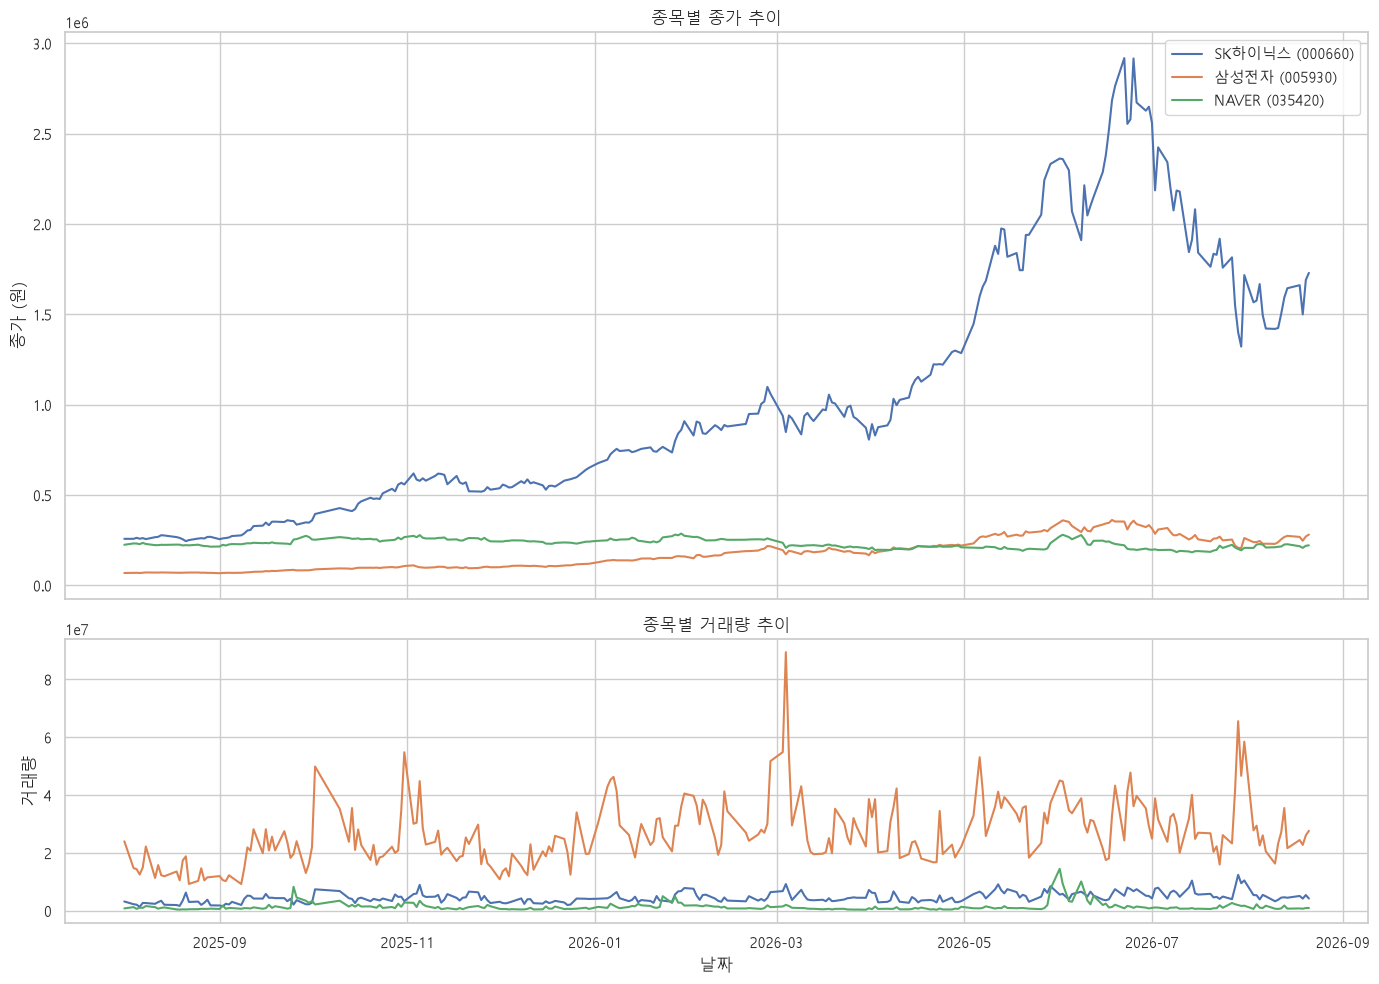

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, height_ratios=[2, 1])

for (ticker, name), group in stocks.groupby(['ticker', 'name']):
    group = group.sort_values('trade_date')
    label = f'{name} ({ticker})'
    axes[0].plot(group['trade_date'], group['close_price'], label=label)
    axes[1].plot(group['trade_date'], group['volume'], label=label)

axes[0].set_title('종목별 종가 추이')
axes[0].set_ylabel('종가 (원)')
axes[1].set_title('종목별 거래량 추이')
axes[1].set_ylabel('거래량')
axes[1].set_xlabel('날짜')
axes[0].legend()
plt.tight_layout()
plt.show()

## 4. 수익률, 변동성, 이동평균

In [5]:
analysis_df = stocks.sort_values(['ticker', 'trade_date']).copy()
grouped_close = analysis_df.groupby('ticker')['close_price']
analysis_df['daily_return'] = grouped_close.pct_change()
analysis_df['ma_5'] = grouped_close.transform(lambda series: series.rolling(5).mean())
analysis_df['ma_20'] = grouped_close.transform(lambda series: series.rolling(20).mean())
analysis_df['ma_60'] = grouped_close.transform(lambda series: series.rolling(60).mean())
analysis_df['rolling_volatility_20'] = (
    analysis_df.groupby('ticker')['daily_return']
    .transform(lambda series: series.rolling(20).std() * (252 ** 0.5))
)

performance_summary = (
    analysis_df.groupby(['ticker', 'name'])
    .agg(
        start_close=('close_price', 'first'),
        end_close=('close_price', 'last'),
        mean_daily_return=('daily_return', 'mean'),
        annualized_volatility=('daily_return', lambda series: series.std() * (252 ** 0.5)),
    )
)
performance_summary['period_return'] = (
    performance_summary['end_close'] / performance_summary['start_close'] - 1
)
performance_summary.sort_values('period_return', ascending=False).style.format({
    'start_close': '{:,.0f}', 'end_close': '{:,.0f}',
    'mean_daily_return': '{:.2%}', 'annualized_volatility': '{:.2%}',
    'period_return': '{:.2%}'
})

,,start_close,end_close,mean_daily_return,annualized_volatility,period_return
ticker,name,,,,,
000660,SK하이닉스,"258,000","1,730,000",0.90%,89.59%,570.54%
005930,삼성전자,"68,900","281,500",0.66%,73.27%,308.56%
035420,NAVER,"225,000","222,000",0.06%,56.58%,-1.33%


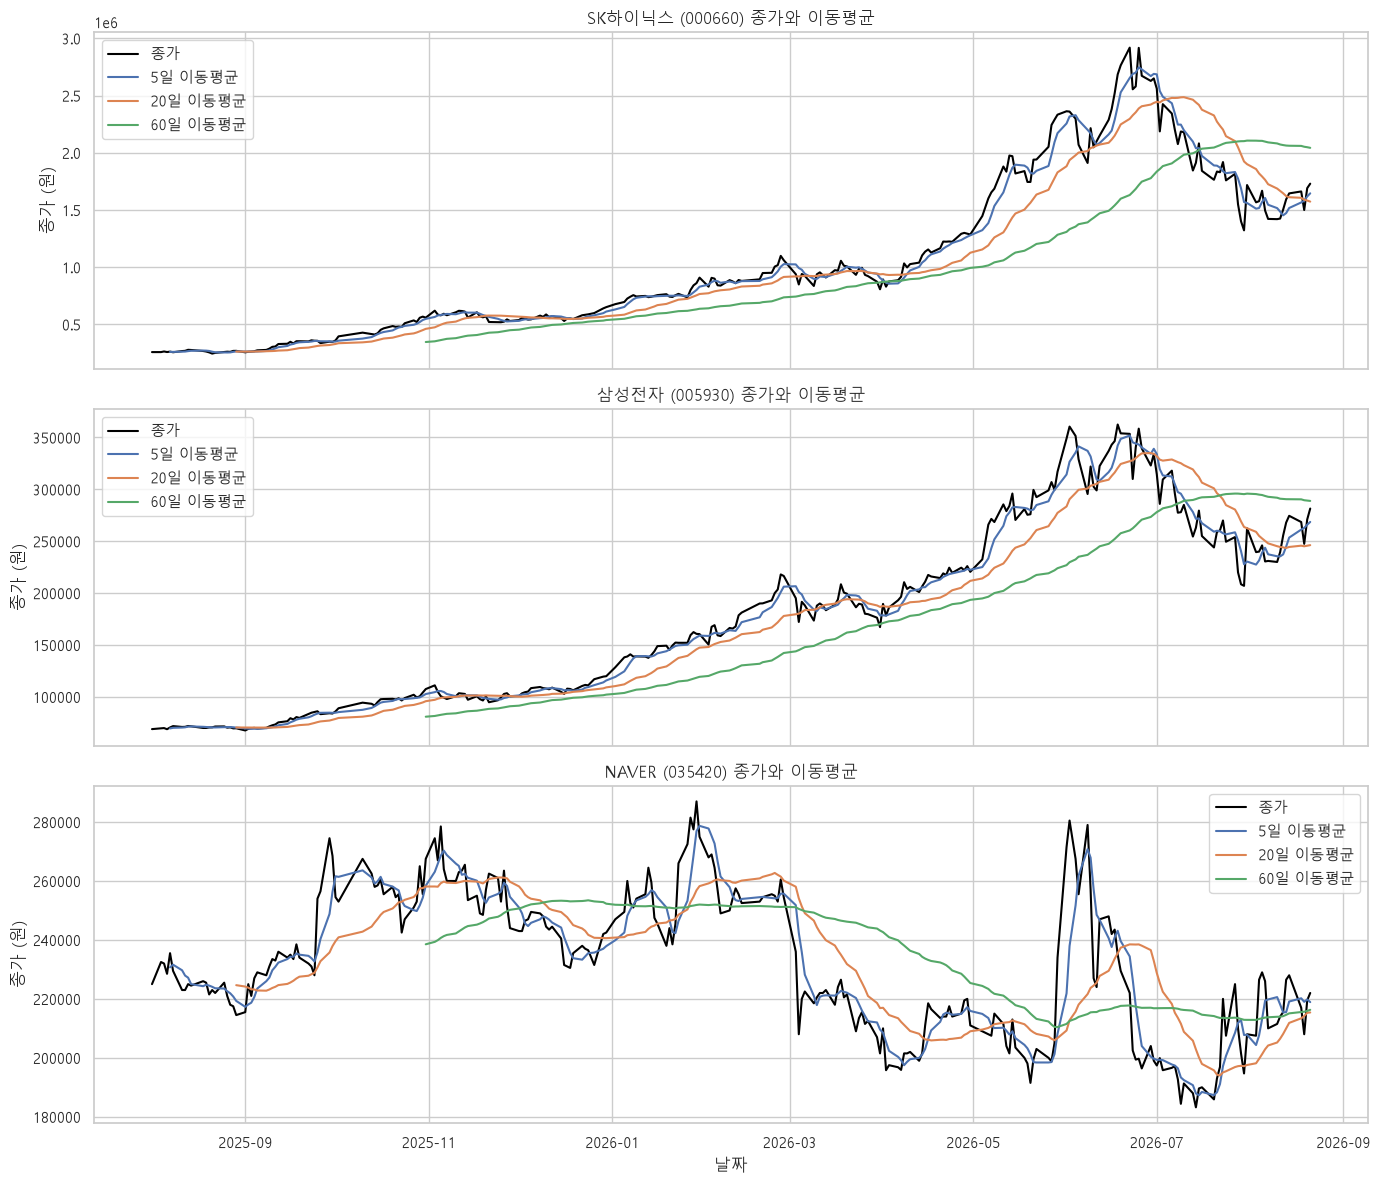

In [6]:
fig, axes = plt.subplots(len(analysis_df['ticker'].unique()), 1, figsize=(14, 4 * len(analysis_df['ticker'].unique())), sharex=True)
axes = [axes] if len(analysis_df['ticker'].unique()) == 1 else axes

for axis, ((ticker, name), group) in zip(axes, analysis_df.groupby(['ticker', 'name'])):
    axis.plot(group['trade_date'], group['close_price'], label='종가', color='black')
    axis.plot(group['trade_date'], group['ma_5'], label='5일 이동평균')
    axis.plot(group['trade_date'], group['ma_20'], label='20일 이동평균')
    axis.plot(group['trade_date'], group['ma_60'], label='60일 이동평균')
    axis.set_title(f'{name} ({ticker}) 종가와 이동평균')
    axis.set_ylabel('종가 (원)')
    axis.legend()

axes[-1].set_xlabel('날짜')
plt.tight_layout()
plt.show()

## 5. KOSPI 대비 수익률과 상관관계

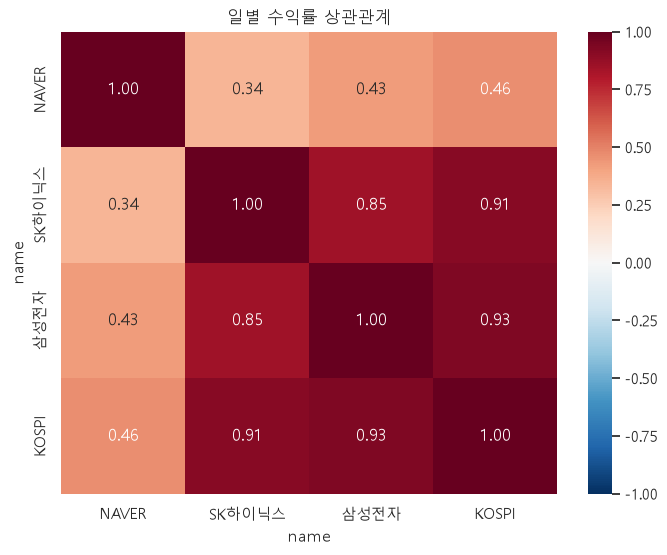

name
KOSPI    1.00
삼성전자     0.93
SK하이닉스   0.91
NAVER    0.46
Name: KOSPI, dtype: float64

In [7]:
kospi['kospi_return'] = kospi['kospi_close'].pct_change()
comparison = analysis_df.merge(kospi[['trade_date', 'kospi_return']], on='trade_date', how='inner')

return_matrix = comparison.pivot(index='trade_date', columns='name', values='daily_return')
return_matrix['KOSPI'] = comparison.drop_duplicates('trade_date').set_index('trade_date')['kospi_return']
correlation = return_matrix.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('일별 수익률 상관관계')
plt.show()

correlation['KOSPI'].sort_values(ascending=False)

## 다음 단계

이 결과를 바탕으로 `feature_engineering.ipynb`에서 수익률, 이동평균, 변동성, 거래량 변화율 및 기술 지표를 모델 입력 피처로 만들고, 다음 날 수익률 또는 상승 여부를 목표값으로 정의합니다.